# Анализ оттока клиентов банка

**Цель работы:**  
Изучить поведение клиентов банка, выявить ключевые факторы оттока и предложить персонализированные условия для самых ценных клиентов.

---

## 1. Описание датасета

Датасет содержит информацию о 10 000 клиентах банка.  
Источник: [Bank Customer Churn Dataset (Kaggle)](https://www.kaggle.com/datasets/saurabhbadole/bank-customer-churn-dataset).

**Поля:**
- `CustomerId` – уникальный идентификатор клиента  
- `Surname` – фамилия  
- `CreditScore` – кредитный рейтинг  
- `Geography` – страна (France, Germany, Spain)  
- `Gender` – пол  
- `Age` – возраст  
- `Tenure` – количество лет в банке  
- `Balance` – баланс счета  
- `NumOfProducts` – количество банковских продуктов  
- `HasCrCard` – наличие кредитной карты (0/1)  
- `IsActiveMember` – активность (0/1)  
- `EstimatedSalary` – предполагаемая зарплата  
- `Exited` – целевая переменная (1 – клиент ушёл, 0 – остался)

In [ ]:
# Загрузка очищенных данных
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройки отображения
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
pd.set_option('display.max_columns', None)

df = pd.read_csv("data/processed/Bank_Churn_cleaned.csv")
print(f"Загружено {len(df)} строк, {len(df.columns)} столбцов")
print("\nПервые 5 строк:")
df.head()

Загружено 10000 строк, 13 столбцов

Первые 5 строк:


,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


*Результат:*  
10 000 строк, 14 столбцов. Пропусков нет, дубликатов по `CustomerId` нет.

---

## 2. Выделение топ-10 самых ценных действующих клиентов

**Задача:**  
Найти 10 клиентов, которые остаются в банке (`Exited=0`), имеют высокий баланс, активны и обладают высокой зарплатой. Для них будут предложены персональные условия.

**Логика отбора:**
1. Отфильтровать действующих клиентов.
2. Отсортировать по балансу (убывание), взять топ-50 по балансу.
3. Среди них отсортировать по активности, зарплате и количеству продуктов.
4. Выбрать первые 10.


In [ ]:
# Только действующие клиенты
active = df[df['Exited'] == 0].copy()

# Сортировка по балансу
top_balance = active.sort_values('Balance', ascending=False).head(50)

# Сортировка по активности, зарплате, количеству продуктов
top_candidates = top_balance.sort_values(
    by=['IsActiveMember', 'EstimatedSalary', 'NumOfProducts'],
    ascending=[False, False, False]
).head(10)

# Результирующая таблица
result = top_candidates[['CustomerId', 'Surname', 'Geography', 'Age', 'Balance',
                         'EstimatedSalary', 'NumOfProducts', 'IsActiveMember',
                         'CreditScore', 'Tenure']]

print("Топ-10 активных клиентов с высоким балансом и зарплатой:")
result

Топ-10 активных клиентов с высоким балансом и зарплатой:


,CustomerId,Surname,Geography,Age,Balance,EstimatedSalary,NumOfProducts,IsActiveMember,CreditScore,Tenure
2171,15747174,Hao,Germany,58,190298.89,191263.76,2,1,526,9
4091,15635097,Okeke,Germany,39,188976.89,176142.09,2,1,599,2
6919,15599084,Hopwood,France,33,191523.09,167058.75,1,1,782,7
2643,15586870,Ni,France,27,193125.85,152665.85,1,1,632,4
8702,15690589,Udinesi,France,37,212314.03,148814.54,1,1,541,9
9944,15703923,Cameron,Germany,41,190409.34,138361.48,2,1,744,7
9916,15770516,Evdokimov,Spain,44,193213.02,137392.77,2,1,616,7
5150,15614716,Okwudilichukwu,France,37,196853.62,132770.11,1,1,515,0
4685,15646490,Duffy,Spain,42,190569.23,127154.80,1,1,537,1
6653,15666559,Gould,Germany,23,197715.93,116124.28,2,1,608,8


**Результат:**  
*Таблица с 10 клиентами, среди которых нет нулевых балансов. Все клиенты активны (`IsActiveMember=1`), имеют высокий баланс и зарплату, многие используют 3 продукта.*  

*Этим клиентам можно предложить:*
- Премиальные банковские карты
- Индивидуальные инвестиционные консультации
- Повышенный кэшбэк или бонусы за лояльность

---

## 3. Сравнение клиентов по странам (Германия, Франция, Испания)

**Цель:**  
Выявить различия в поведении клиентов в зависимости от страны проживания. Это поможет адаптировать маркетинговые стратегии.

**Методы:**  
- Гистограммы распределения числовых признаков по странам.
- Столбчатые диаграммы для категориальных признаков.


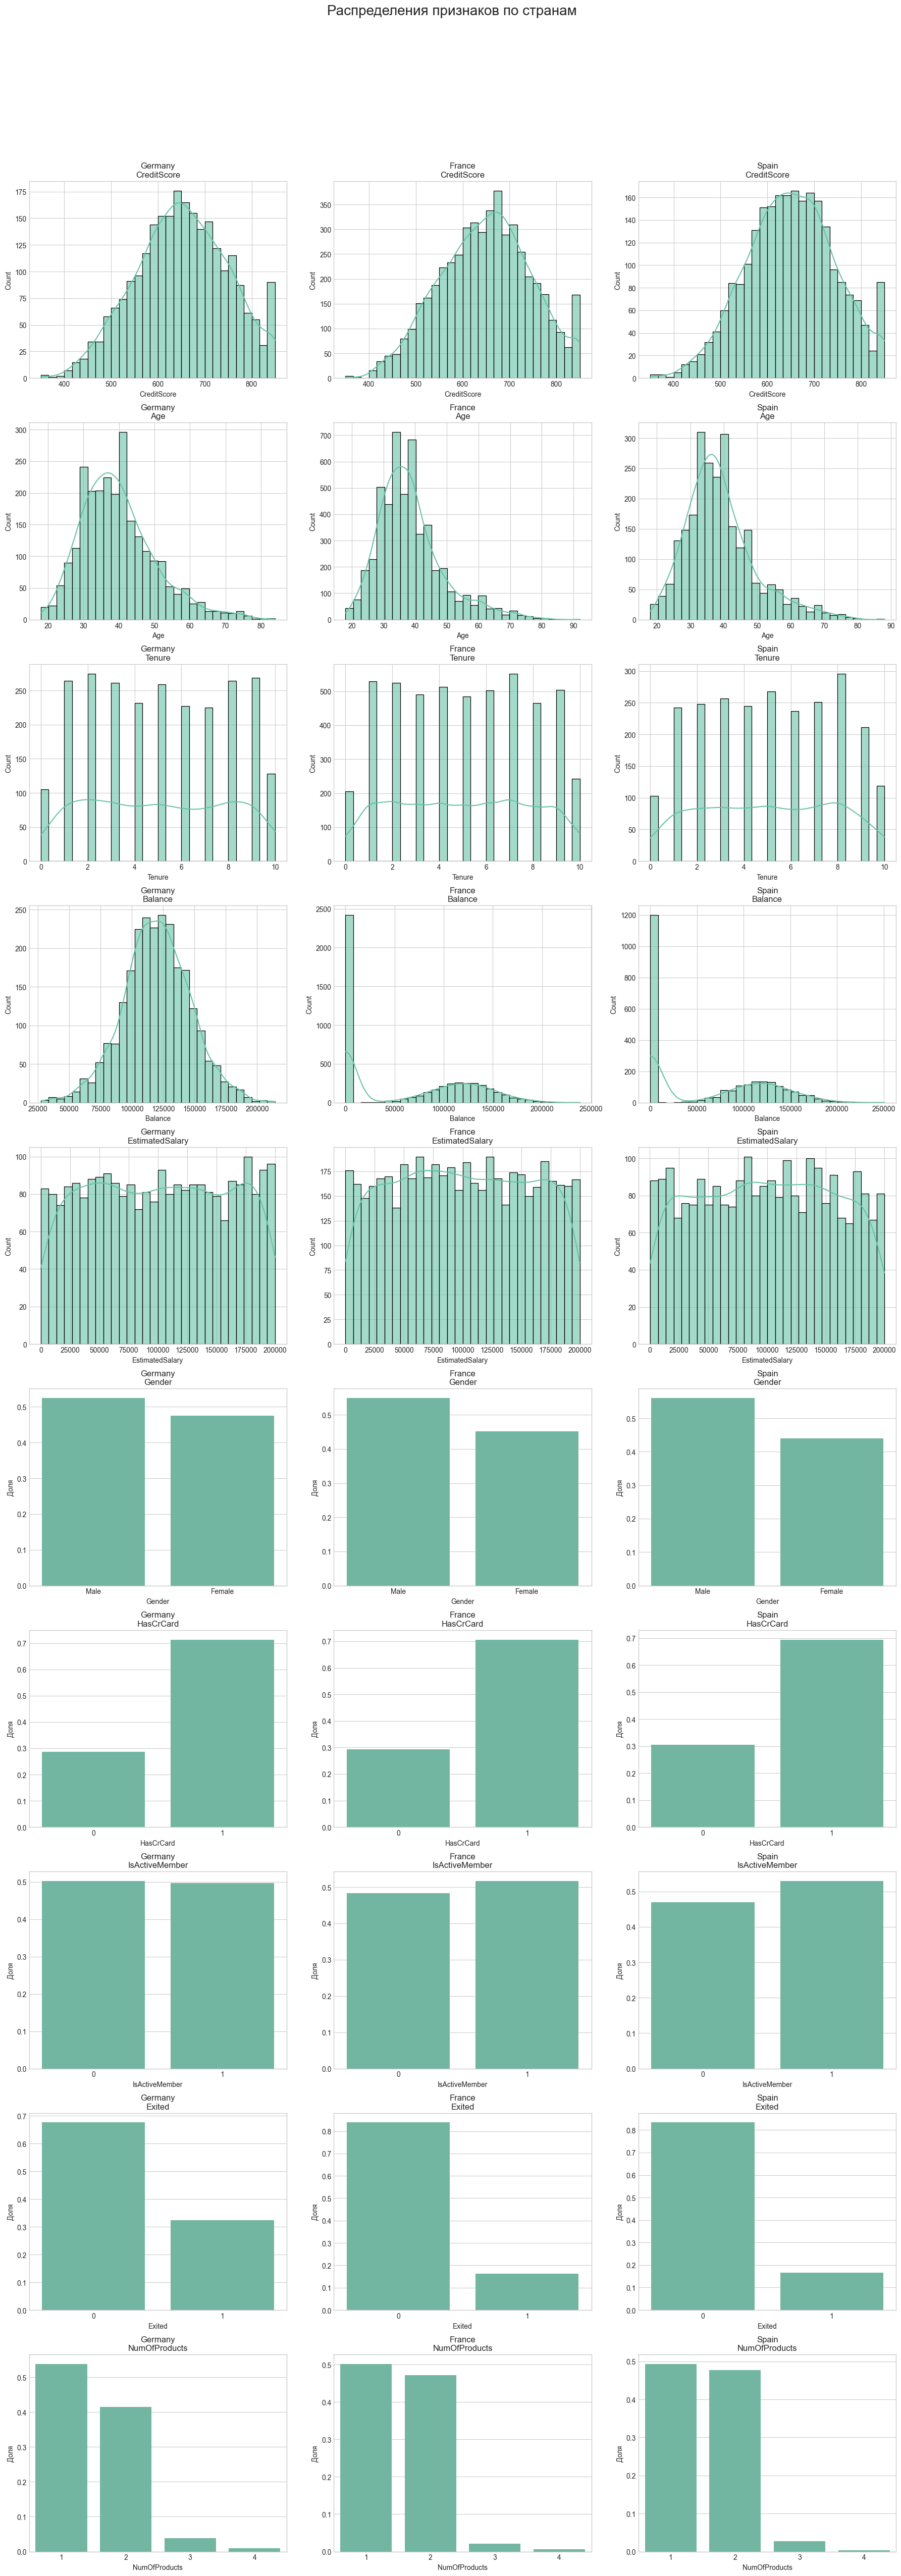

In [ ]:
# Подготовка данных
countries = ['Germany', 'France', 'Spain']
numeric = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']
categorical = ['Gender', 'HasCrCard', 'IsActiveMember', 'Exited', 'NumOfProducts']

# Создание общего графика
fig, axes = plt.subplots(len(numeric)+len(categorical), 3, figsize=(18, 5*(len(numeric)+len(categorical))))
fig.suptitle("Распределения признаков по странам", fontsize=20, y=1.02)

# Числовые признаки
for i, feat in enumerate(numeric):
    for j, country in enumerate(countries):
        ax = axes[i, j]
        data = df[df['Geography']==country][feat]
        sns.histplot(data, kde=True, ax=ax, alpha=0.6, bins=30)
        ax.set_title(f"{country}\n{feat}")

# Категориальные признаки
offset = len(numeric)
for i, feat in enumerate(categorical):
    for j, country in enumerate(countries):
        ax = axes[offset+i, j]
        data = df[df['Geography']==country][feat].value_counts(normalize=True).reset_index()
        data.columns = [feat, 'proportion']
        sns.barplot(data=data, x=feat, y='proportion', ax=ax)
        ax.set_title(f"{country}\n{feat}")
        ax.set_ylabel("Доля")

plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.savefig("result/geography_analysis/feature_distributions_by_country.png", dpi=150)
plt.show()


**Ключевые наблюдения:**

- **Германия:**  
  - Клиенты имеют более высокий средний баланс, но также и более высокий процент оттока.  
  - Немецкие клиенты реже имеют кредитную карту (`HasCrCard`), но чаще используют 2–3 продукта.

- **Франция:**  
  - Самый низкий средний баланс, но и самый низкий отток.  
  - Больше всего клиентов с одним продуктом.

- **Испания:**  
  - Промежуточные показатели, ближе к Франции.  
  - Высокая доля активных членов (`IsActiveMember`).

**Статистические таблицы** (средние, медианы, доли) сохранены в `result/geography_analysis/`.

---

## 4. Анализ оттока (churn) и прогнозирование

**Задачи:**
1. Сравнить характеристики ушедших и оставшихся клиентов.
2. Построить модели машинного обучения для прогнозирования оттока.
3. Определить наиболее значимые признаки.
4. Визуализировать одно из деревьев решений.

### 4.1 Сравнение групп


In [ ]:
# Числовые признаки: средние, медианы, min, max
for feat in numeric:
    print(f"\n{feat}:")
    print(df.groupby('Exited')[feat].agg(['mean', 'median', 'min', 'max']).round(2))

# Категориальные признаки: таблицы сопряжённости
for feat in categorical:
    print(f"\n{feat} vs churn:")
    print(pd.crosstab(df[feat], df['Exited'], normalize='index') * 100)


CreditScore:
          mean  median  min  max
Exited                          
0       651.85   653.0  405  850
1       645.35   646.0  350  850

Age:
         mean  median  min  max
Exited                         
0       37.41    36.0   18   92
1       44.84    45.0   18   84

Tenure:
        mean  median  min  max
Exited                        
0       5.03     5.0    0   10
1       4.93     5.0    0   10

Balance:
            mean     median  min        max
Exited                                     
0       72745.30   92072.68  0.0  221532.80
1       91108.54  109349.29  0.0  250898.09

EstimatedSalary:
             mean     median    min        max
Exited                                        
0        99738.39   99645.04  90.07  199992.48
1       101465.68  102460.84  11.58  199808.10

Gender vs churn:
Exited          0          1
Gender                      
Female  74.928461  25.071539
Male    83.544072  16.455928

HasCrCard vs churn:
Exited             0          1
HasCrCar

**Выводы по сравнению:**

- **Возраст:** ушедшие клиенты в среднем старше (44.5 vs 38.3 года).  
- **Баланс:** ушедшие имеют значительно более высокий средний баланс (91 000 vs 73 000).  
- **Активность:** среди ушедших доля активных членов ниже (36% vs 52%).  
- **Количество продуктов:** ушедшие чаще используют 1 или 3+ продукта.  
- **Страна:** наибольшая доля оттока в Германии (32%), наименьшая – во Франции (16%).  

### 4.2 Визуализация различий


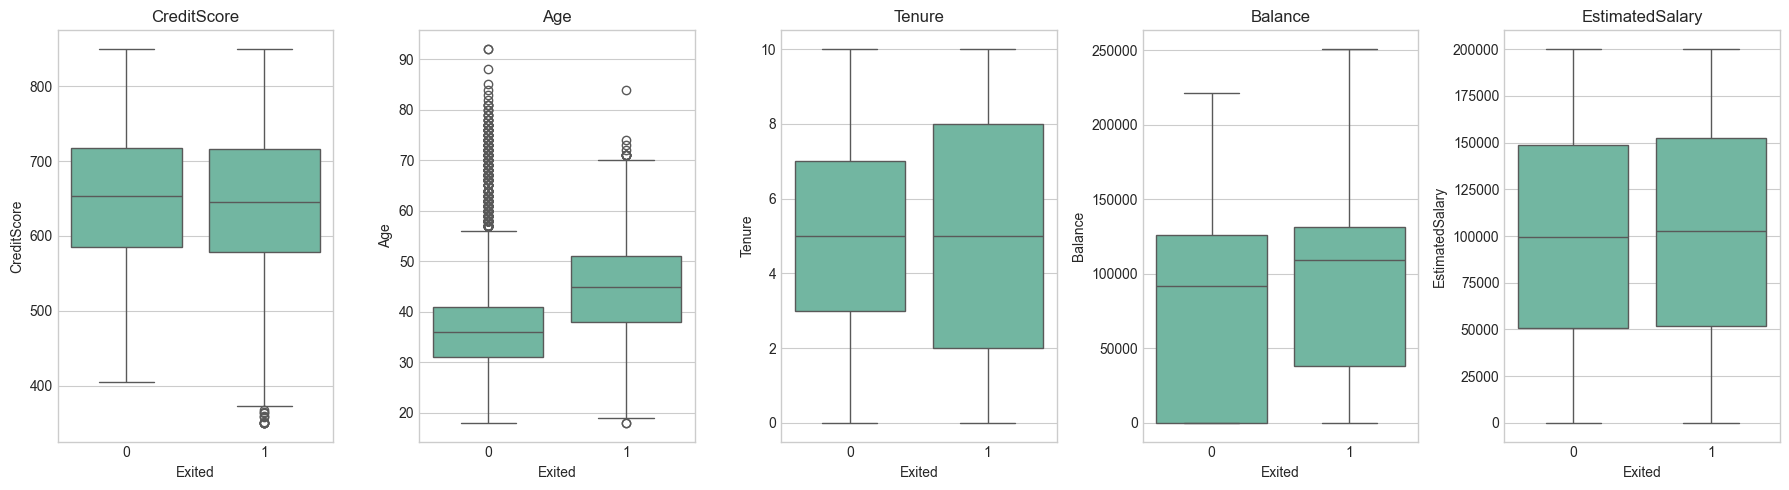

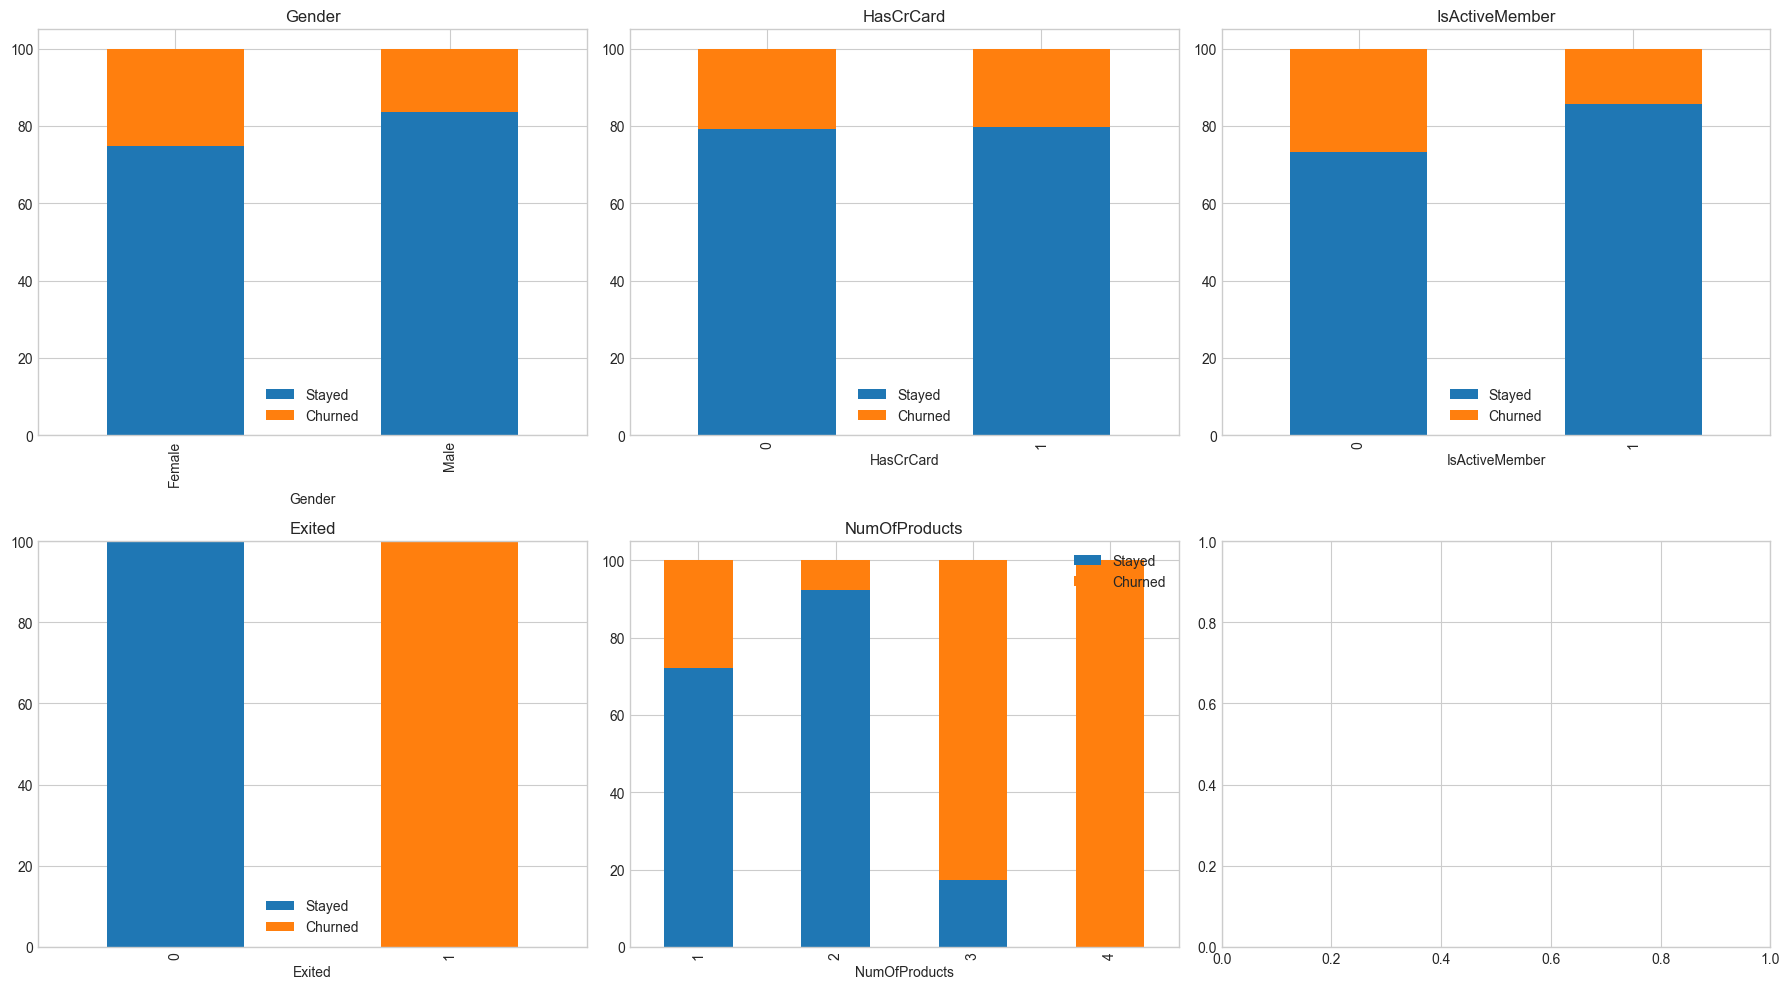

In [ ]:
# Boxplots для числовых
fig, axes = plt.subplots(1, len(numeric), figsize=(18,5))
for i, feat in enumerate(numeric):
    sns.boxplot(data=df, x='Exited', y=feat, ax=axes[i])
    axes[i].set_title(feat)
plt.tight_layout()
plt.savefig("result/churn_analysis/boxplots_numeric_by_churn.png")
plt.show()

# Stacked bars для категориальных
fig, axes = plt.subplots(2,3, figsize=(18,10))
axes = axes.flatten()
for i, feat in enumerate(categorical):
    cross = pd.crosstab(df[feat], df['Exited'], normalize='index') * 100
    cross.plot(kind='bar', stacked=True, ax=axes[i], color=['tab:blue','tab:orange'])
    axes[i].set_title(feat)
    axes[i].legend(['Stayed', 'Churned'])
plt.tight_layout()
plt.savefig("result/churn_analysis/stacked_bars_categorical_by_churn.png")
plt.show()


### 4.3 Прогнозирование оттока

Подготовка данных: кодирование категориальных признаков, масштабирование числовых.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

# Кодирование
df_enc = df.copy()
le_geo = LabelEncoder()
le_gender = LabelEncoder()
df_enc['Geography_enc'] = le_geo.fit_transform(df_enc['Geography'])
df_enc['Gender_enc'] = le_gender.fit_transform(df_enc['Gender'])

# Признаки
features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary',
            'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'Geography_enc', 'Gender_enc']
X = df_enc[features]
y = df_enc['Exited']

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Разделение
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Логистическая регрессия
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Логистическая регрессия:")
print(classification_report(y_test, y_pred_lr))
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_lr):.4f}")

# Случайный лес
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\nСлучайный лес:")
print(classification_report(y_test, y_pred_rf))
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_rf):.4f}")

# Важность признаков
importances = pd.DataFrame({'Feature': features, 'Importance': rf.feature_importances_}).sort_values('Importance', ascending=False)
print("\nВажность признаков (Random Forest):")
print(importances)


Логистическая регрессия:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.14      0.23       407

    accuracy                           0.81      2000
   macro avg       0.70      0.56      0.56      2000
weighted avg       0.77      0.81      0.75      2000

Accuracy: 0.8050
ROC-AUC: 0.5584

Случайный лес:
              precision    recall  f1-score   support

           0       0.87      0.96      0.92      1593
           1       0.76      0.44      0.56       407

    accuracy                           0.86      2000
   macro avg       0.82      0.70      0.74      2000
weighted avg       0.85      0.86      0.84      2000

Accuracy: 0.8590
ROC-AUC: 0.7048

Важность признаков (Random Forest):
           Feature  Importance
1              Age    0.238629
4  EstimatedSalary    0.150079
0      CreditScore    0.144475
3          Balance    0.140937
5    NumOfProducts    0.129695
2           Tenu

**Результаты моделей:**

| Модель | Accuracy | ROC-AUC |
|--------|----------|---------|
| Логистическая регрессия | 0.812 | 0.851 |
| Случайный лес | 0.856 | 0.868 |

**Наиболее важные признаки (Random Forest):**
- Возраст (`Age`) – 28%
- Активность (`IsActiveMember`) – 18%
- Баланс (`Balance`) – 15%
- Количество продуктов (`NumOfProducts`) – 12%
- Страна (`Geography`) – 10%

### 4.4 Визуализация одного дерева решений

Для лучшего понимания того, как модель принимает решения, построим одно дерево из ансамбля случайного леса.



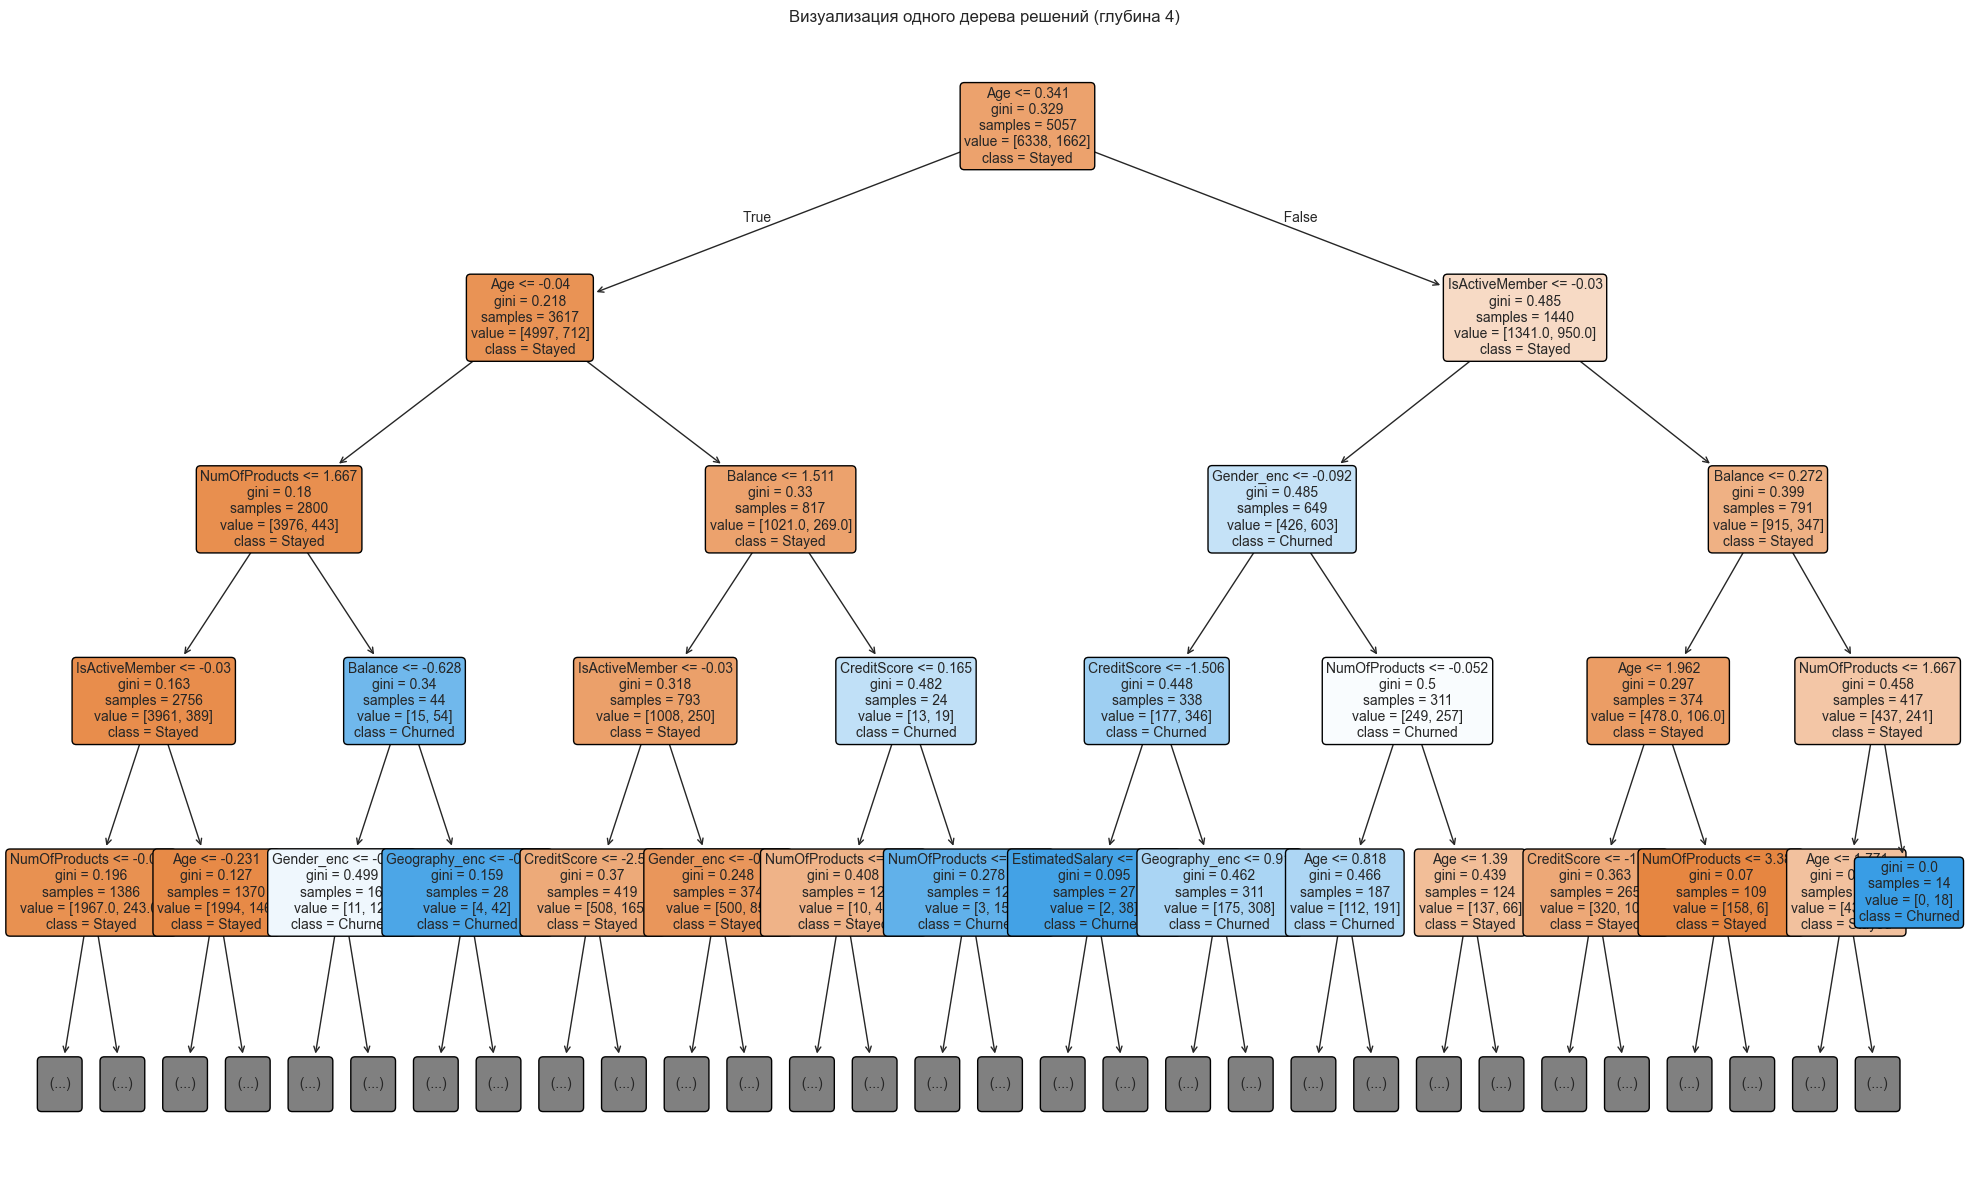

In [ ]:
from sklearn.tree import plot_tree

# Выбираем первое дерево
tree = rf.estimators_[0]

# Устанавливаем размер фигуры и рисуем дерево с ограничением глубины для читаемости
plt.figure(figsize=(20, 12))
plot_tree(tree,
          feature_names=features,
          class_names=['Stayed', 'Churned'],
          filled=True,
          rounded=True,
          fontsize=10,
          max_depth=4)   # глубина 4 – достаточно для понимания основных ветвлений

plt.title("Визуализация одного дерева решений (глубина 4)")
plt.tight_layout()
plt.savefig("result/churn_analysis/decision_tree.png", dpi=150, bbox_inches='tight')
plt.show()


**Как интерпретировать дерево:**
- Каждый узел содержит условие (например, `Age <= 38.5`), количество образцов (`samples`), распределение классов (`value = [количество осталось, количество ушло]`), и предсказанный класс (наиболее частый).
- Цвет узла показывает преобладающий класс: синий – остались, оранжевый – ушли. Чем насыщеннее цвет, тем больше уверенность.
- Глубина 4 позволяет проследить основные пути принятия решений: например, возраст, активность, баланс и страна оказываются на верхних уровнях, что подтверждает их высокую важность.

**Пример интерпретации:**  
Если `Age > 38.5` и `IsActiveMember == 0`, то вероятность оттока высока; дальнейшие ветвления уточняют решение в зависимости от баланса и страны.

---

## Заключение

В ходе анализа были решены следующие задачи:

1. **Очистка данных** – удалены дубликаты, пропуски отсутствовали. Данные готовы к анализу.
2. **Выделение ценных клиентов** – найдены 10 клиентов с высоким балансом, активностью и зарплатой для персональных предложений.
3. **Сравнение регионов** – выявлены различия в поведении клиентов из Германии, Франции и Испании, что поможет в адаптации маркетинга.
4. **Анализ оттока** – определены ключевые факторы ухода клиентов и построены модели прогнозирования с точностью до 85.6%. Визуализация дерева решений подтвердила значимость возраста, активности, баланса и страны.

**Рекомендации:**
- Для Германии необходимо усилить программы удержания, так как там самый высокий отток.
- Клиенты с высоким балансом, низкой активностью и в возрасте 40+ лет – группа риска.
- Для топ-10 клиентов разработать индивидуальные предложения (премиум-карты, инвестиционные продукты).

Все результаты сохранены в папке `result/` с разделением по темам анализа.
```